# Model Pruning: Making Neural Networks Sparse and Efficient

**Model pruning** is a fundamental technique for compressing neural networks by removing redundant weights or structures. This enables deployment on resource-constrained devices while maintaining accuracy.

## What You'll Learn

This notebook builds deep intuitions about model pruning through hands-on implementation:

1. **Why pruning works** - neural network over-parameterization and redundancy
2. **Unstructured pruning** - removing individual weights (fine-grained sparsity)
3. **Structured pruning** - removing entire neurons, filters, or channels
4. **Magnitude-based pruning** - using weight magnitudes as importance scores
5. **Iterative pruning** - gradually increasing sparsity with fine-tuning
6. **PyTorch pruning utilities** - practical implementation patterns

## Why Pruning Matters

Neural networks are **massively over-parameterized**:
- Studies show 90%+ of weights can be removed with minimal accuracy loss
- Redundant weights waste computation and memory
- Sparse networks can be accelerated on specialized hardware

Pruning enables:
- **Smaller models**: 10-100x parameter reduction
- **Faster inference**: Fewer operations to compute
- **Lower memory**: Sparse representations are compact
- **Energy efficiency**: Critical for edge/mobile deployment

## Pruning vs Other Compression Techniques

| Technique | What It Does | Compression | Hardware Support |
|-----------|-------------|-------------|------------------|
| **Pruning** | Removes weights/structures | 10-100x fewer params | Sparse accelerators |
| **Quantization** | Reduces precision (FP32→INT8) | 4x smaller | Wide support |
| **Distillation** | Trains smaller architecture | Architecture-dependent | Universal |

These techniques are **complementary** - you can prune, then quantize, then distill!


## Setup


In [1]:
# Standard library imports
import copy
from typing import Tuple, Dict, List

# Third-party imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torch.nn.utils.prune as prune
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# Local library imports
from aiml_notebooks import (
    get_device, set_seed, count_parameters,
    create_dataset, create_dataloaders,
    get_dataset_config,
)

# Enable autoreload for hot reloading of library changes
%load_ext autoreload
%autoreload 2

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch version: 2.9.0+cu128
CUDA available: True


In [2]:
# Set random seed for reproducibility
set_seed(42)

# Configure device
device = get_device()
print(f"Using device: {device}")


Using CUDA GPU: NVIDIA GeForce RTX 4090
Using device: cuda


## Part 1: Understanding Neural Network Redundancy

### The Lottery Ticket Hypothesis

A landmark paper by Frankle & Carlin (2019) showed that:

> "Dense, randomly-initialized networks contain sparse subnetworks (winning tickets) that can train to full accuracy in isolation."

This means most weights in a neural network are **unnecessary** - they just help optimization find a good solution. After training, we can remove them!

### Why Over-Parameterization Helps Training

1. **Easier optimization**: More parameters = smoother loss landscape
2. **Implicit regularization**: SGD prefers simpler solutions in over-parameterized models
3. **Feature diversity**: Many paths to learn different aspects of data

But for **inference**, we don't need all this redundancy!


In [3]:
# Define a simple CNN for demonstration
class SimpleNet(nn.Module):
    """Simple CNN for demonstration."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Initialize and examine
model = SimpleNet()
print(f"Model parameters: {count_parameters(model):,}")


Model parameters: 102,602


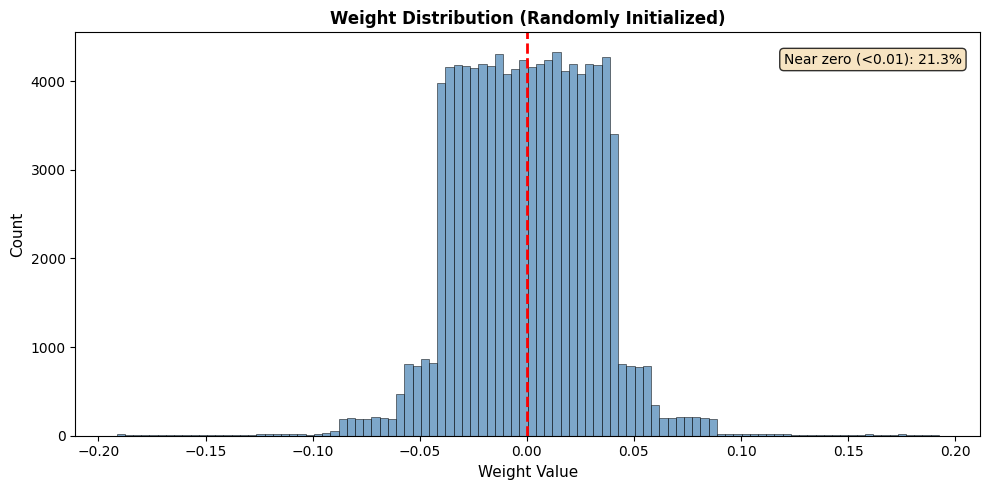

Total weights: 101,856
Mean: 0.0000, Std: 0.0314


In [4]:
# Utilities for weight analysis and visualization
def get_all_weights(model):
    """Collect all weights from a model into a single tensor."""
    weights = []
    for name, param in model.named_parameters():
        if 'weight' in name and param.dim() > 1:  # Skip biases and 1D params
            weights.append(param.data.cpu().flatten())
    return torch.cat(weights)

def plot_weight_distribution(weights, title, ax=None, color='steelblue'):
    """Plot histogram of weight values."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    
    weights_np = weights.numpy()
    ax.hist(weights_np, bins=100, color=color, alpha=0.7, edgecolor='black', linewidth=0.5)
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
    ax.set_xlabel('Weight Value', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    # Add statistics
    near_zero = (np.abs(weights_np) < 0.01).sum() / len(weights_np) * 100
    ax.text(0.98, 0.95, f'Near zero (<0.01): {near_zero:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    return ax

# Plot initial weights (before training)
initial_weights = get_all_weights(model)
fig, ax = plt.subplots(figsize=(10, 5))
plot_weight_distribution(initial_weights, 'Weight Distribution (Randomly Initialized)', ax)
plt.tight_layout()
plt.show()

print(f"Total weights: {len(initial_weights):,}")
print(f"Mean: {initial_weights.mean():.4f}, Std: {initial_weights.std():.4f}")


## Part 2: Load Dataset and Train Base Model

We'll train a model on CIFAR-10, then prune it to see how much we can compress without losing accuracy.


In [5]:
# Get CIFAR-10 configuration
dataset_config = get_dataset_config('cifar10')
class_names = dataset_config['classes']
num_classes = len(class_names)

print(f"Dataset: CIFAR-10")
print(f"Number of classes: {num_classes}")
print(f"Classes: {', '.join(class_names)}")


Dataset: CIFAR-10
Number of classes: 10
Classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck


In [6]:
# Load CIFAR-10 dataset
train_dataset, test_dataset = create_dataset(dataset_id='cifar10')

# Create data loaders
BATCH_SIZE = 128
train_loader, test_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=2,
    use_collate_fn=False
)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_dataset):,} samples")
print(f"  Test: {len(test_dataset):,} samples")



Dataset sizes:
  Train: 50,000 samples
  Test: 10,000 samples


In [7]:
# Training utilities
def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    return total_loss / total, 100. * correct / total

def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataset."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            total_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    return total_loss / total, 100. * correct / total


In [8]:
# Train the base model
model = SimpleNet(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

print("Training base model...")
print(f"Parameters: {count_parameters(model):,}")
print("-" * 60)

EPOCHS = 20
best_acc = 0
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in tqdm(range(EPOCHS), desc="Training"):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    if test_acc > best_acc:
        best_acc = test_acc
        best_model_state = copy.deepcopy(model.state_dict())

print(f"\nBest test accuracy: {best_acc:.2f}%")

# Load best model
model.load_state_dict(best_model_state)


Training base model...
Parameters: 102,602
------------------------------------------------------------


Training:   0%|          | 0/20 [00:00<?, ?it/s]


Best test accuracy: 75.85%


<All keys matched successfully>

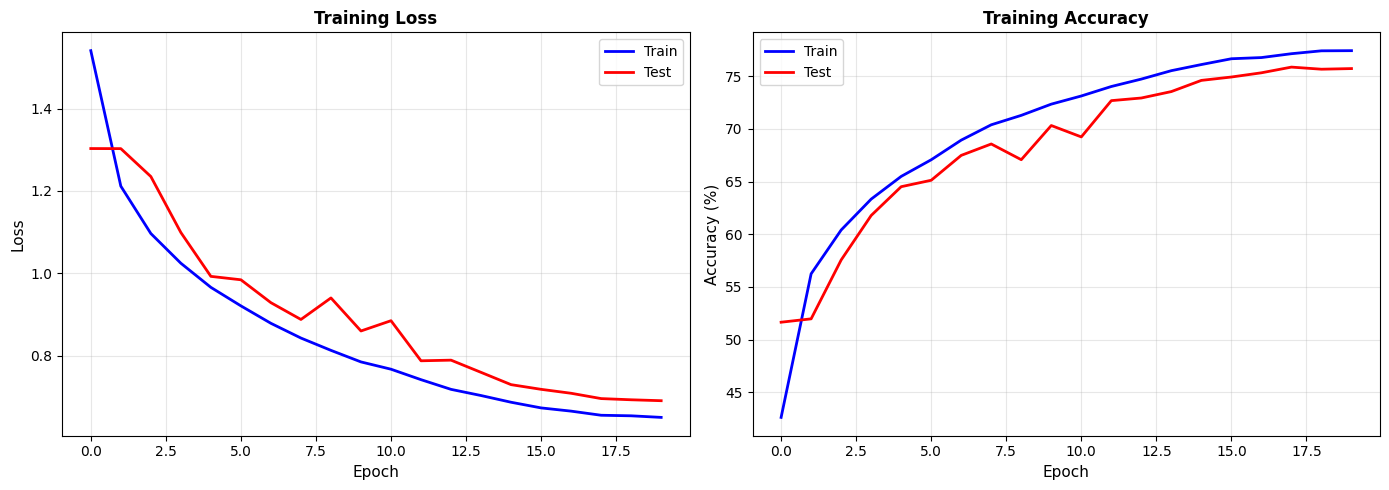

In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(history['test_loss'], 'r-', label='Test', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Training Loss', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], 'b-', label='Train', linewidth=2)
axes[1].plot(history['test_acc'], 'r-', label='Test', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_title('Training Accuracy', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


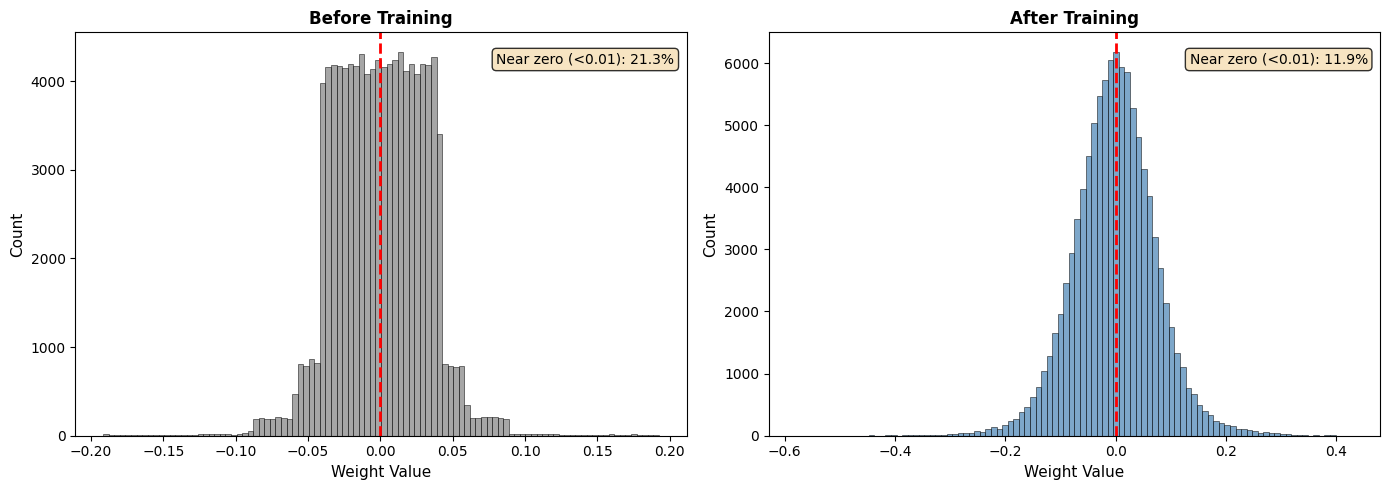


Weights near zero (<0.01): 11.9%
These small weights contribute little and can be pruned!


In [10]:
# Visualize weight distribution after training
trained_weights = get_all_weights(model)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_weight_distribution(initial_weights, 'Before Training', axes[0], color='gray')
plot_weight_distribution(trained_weights, 'After Training', axes[1], color='steelblue')
plt.tight_layout()
plt.show()

# Many weights are now near zero - perfect candidates for pruning!
near_zero_pct = (trained_weights.abs() < 0.01).float().mean() * 100
print(f"\nWeights near zero (<0.01): {near_zero_pct:.1f}%")
print("These small weights contribute little and can be pruned!")


## Part 3: Unstructured Pruning

**Unstructured pruning** removes individual weights based on some criterion (typically magnitude).

### How It Works

1. Train a dense model to convergence
2. Rank all weights by importance (e.g., |weight|)
3. Set the smallest weights to zero
4. (Optional) Fine-tune to recover accuracy

### Pros and Cons

| Pros | Cons |
|------|------|
| Very high sparsity (90%+) | Irregular memory access |
| Minimal accuracy loss | Needs sparse hardware/libraries |
| Fine-grained control | Dense storage unless compressed |


In [11]:
# Implement magnitude-based unstructured pruning from scratch

def compute_sparsity(model):
    """Compute the percentage of zero weights in the model."""
    total_params = 0
    zero_params = 0
    
    for name, param in model.named_parameters():
        if 'weight' in name:
            total_params += param.numel()
            zero_params += (param == 0).sum().item()
    
    return 100.0 * zero_params / total_params if total_params > 0 else 0

def magnitude_prune_model(model, amount):
    """
    Globally prune a model by magnitude.
    
    Args:
        model: The neural network
        amount: Fraction of weights to prune globally
    """
    # Collect all weight magnitudes
    all_weights = []
    for name, module in model.named_modules():
        if hasattr(module, 'weight') and module.weight is not None:
            if module.weight.dim() > 1:  # Skip 1D params (batch norm)
                all_weights.append(module.weight.data.abs().flatten())
    
    all_weights = torch.cat(all_weights)
    num_prune = int(len(all_weights) * amount)
    
    if num_prune == 0:
        return
    
    # Find global threshold
    threshold = torch.kthvalue(all_weights, num_prune).values
    
    # Apply pruning
    for name, module in model.named_modules():
        if hasattr(module, 'weight') and module.weight is not None:
            if module.weight.dim() > 1:
                mask = module.weight.data.abs() > threshold
                module.weight.data *= mask.float()

print("Pruning functions defined!")


Pruning functions defined!


In [12]:
# Test pruning at different sparsity levels
print("Testing different pruning levels on trained model:")
print("=" * 60)

sparsity_levels = [0.0, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95]
results = []

for sparsity in sparsity_levels:
    # Create a fresh copy of the trained model
    pruned_model = SimpleNet(num_classes=num_classes).to(device)
    pruned_model.load_state_dict(copy.deepcopy(best_model_state))
    
    # Apply pruning
    magnitude_prune_model(pruned_model, sparsity)
    
    # Evaluate
    _, acc = evaluate(pruned_model, test_loader, criterion, device)
    actual_sparsity = compute_sparsity(pruned_model)
    
    results.append({
        'target_sparsity': sparsity * 100,
        'actual_sparsity': actual_sparsity,
        'accuracy': acc,
    })
    
    print(f"Sparsity: {sparsity*100:5.1f}% → Actual: {actual_sparsity:5.1f}% | Accuracy: {acc:.2f}%")

print("=" * 60)


Testing different pruning levels on trained model:
Sparsity:   0.0% → Actual:   0.0% | Accuracy: 75.85%
Sparsity:  30.0% → Actual:  29.9% | Accuracy: 71.27%
Sparsity:  50.0% → Actual:  49.9% | Accuracy: 55.06%
Sparsity:  70.0% → Actual:  69.8% | Accuracy: 23.78%
Sparsity:  80.0% → Actual:  79.8% | Accuracy: 11.22%
Sparsity:  90.0% → Actual:  89.8% | Accuracy: 10.32%
Sparsity:  95.0% → Actual:  94.8% | Accuracy: 9.78%


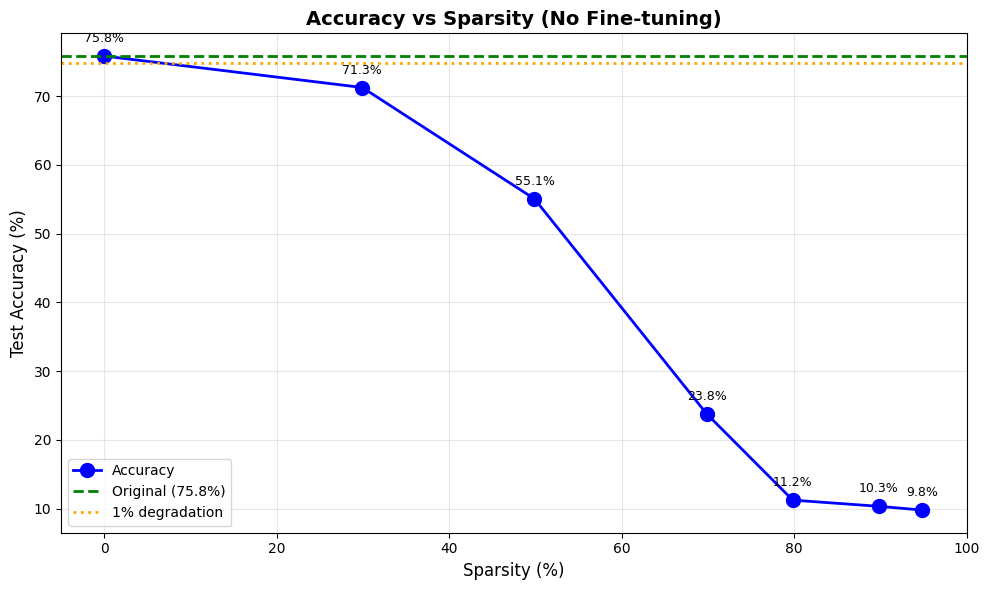


Key insight: We can prune ~50-70% of weights with minimal accuracy loss!
At 90%+ sparsity, accuracy degrades - but fine-tuning can help recover it.


In [13]:
# Visualize accuracy vs sparsity tradeoff
fig, ax = plt.subplots(figsize=(10, 6))

sparsities = [r['actual_sparsity'] for r in results]
accuracies = [r['accuracy'] for r in results]

ax.plot(sparsities, accuracies, 'bo-', markersize=10, linewidth=2, label='Accuracy')
ax.axhline(y=best_acc, color='green', linestyle='--', linewidth=2, label=f'Original ({best_acc:.1f}%)')
ax.axhline(y=best_acc - 1, color='orange', linestyle=':', linewidth=2, label='1% degradation')

# Annotate points
for s, a in zip(sparsities, accuracies):
    ax.annotate(f'{a:.1f}%', (s, a), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs Sparsity (No Fine-tuning)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 100)

plt.tight_layout()
plt.show()

print("\nKey insight: We can prune ~50-70% of weights with minimal accuracy loss!")
print("At 90%+ sparsity, accuracy degrades - but fine-tuning can help recover it.")


## Part 4: Iterative Pruning with Fine-tuning

**One-shot pruning** (removing all weights at once) often causes accuracy degradation at high sparsity.

**Iterative pruning** gradually increases sparsity with fine-tuning between rounds:

1. Train dense model
2. Prune a small fraction (e.g., 20%)
3. Fine-tune for a few epochs
4. Repeat until target sparsity

This gives the model time to adapt and redistribute importance to remaining weights.


In [14]:
def iterative_prune(
    model,
    train_loader,
    test_loader,
    target_sparsity: float,
    num_iterations: int,
    finetune_epochs: int,
    device,
    lr: float = 0.0001,
):
    """
    Iteratively prune a model with fine-tuning between rounds.
    
    Args:
        model: The neural network to prune
        target_sparsity: Final sparsity target (0.0 to 1.0)
        num_iterations: Number of pruning rounds
        finetune_epochs: Epochs to fine-tune between rounds
    
    Returns:
        Pruned model and history of metrics
    """
    criterion = nn.CrossEntropyLoss()
    history = {'iteration': [], 'sparsity': [], 'accuracy': []}
    
    # Calculate sparsity per iteration
    prune_per_iter = 1 - (1 - target_sparsity) ** (1 / num_iterations)
    
    print(f"Target sparsity: {target_sparsity*100:.1f}%")
    print(f"Pruning {prune_per_iter*100:.1f}% per iteration over {num_iterations} iterations")
    print("=" * 70)
    
    # Initial evaluation
    _, initial_acc = evaluate(model, test_loader, criterion, device)
    history['iteration'].append(0)
    history['sparsity'].append(compute_sparsity(model))
    history['accuracy'].append(initial_acc)
    print(f"Initial: Sparsity = {history['sparsity'][-1]:.1f}%, Accuracy = {initial_acc:.2f}%")
    
    for iteration in range(1, num_iterations + 1):
        # Global magnitude pruning on non-zero weights
        all_weights = []
        for name, module in model.named_modules():
            if hasattr(module, 'weight') and module.weight is not None:
                if module.weight.dim() > 1:
                    nonzero_weights = module.weight.data[module.weight.data != 0].abs()
                    all_weights.append(nonzero_weights.flatten())
        
        if len(all_weights) > 0:
            all_weights = torch.cat(all_weights)
            num_to_prune = int(len(all_weights) * prune_per_iter)
            
            if num_to_prune > 0:
                threshold = torch.kthvalue(all_weights, num_to_prune).values
                
                for name, module in model.named_modules():
                    if hasattr(module, 'weight') and module.weight is not None:
                        if module.weight.dim() > 1:
                            mask = module.weight.data.abs() > threshold
                            mask = mask | (module.weight.data == 0)
                            module.weight.data *= mask.float()
        
        # Fine-tune
        optimizer = optim.Adam(model.parameters(), lr=lr)
        for epoch in range(finetune_epochs):
            train_epoch(model, train_loader, optimizer, criterion, device)
        
        # Evaluate
        _, acc = evaluate(model, test_loader, criterion, device)
        sparsity = compute_sparsity(model)
        
        history['iteration'].append(iteration)
        history['sparsity'].append(sparsity)
        history['accuracy'].append(acc)
        
        print(f"Iteration {iteration}/{num_iterations}: Sparsity = {sparsity:.1f}%, Accuracy = {acc:.2f}%")
    
    print("=" * 70)
    return model, history


In [15]:
# Apply iterative pruning to reach 90% sparsity
print("\nIterative Pruning with Fine-tuning")
print("="*70)

# Fresh copy of trained model
model_iterative = SimpleNet(num_classes=num_classes).to(device)
model_iterative.load_state_dict(copy.deepcopy(best_model_state))

model_iterative, iter_history = iterative_prune(
    model=model_iterative,
    train_loader=train_loader,
    test_loader=test_loader,
    target_sparsity=0.90,
    num_iterations=10,
    finetune_epochs=2,
    device=device,
    lr=0.0001,
)



Iterative Pruning with Fine-tuning
Target sparsity: 90.0%
Pruning 20.6% per iteration over 10 iterations
Initial: Sparsity = 0.0%, Accuracy = 75.85%
Iteration 1/10: Sparsity = 0.2%, Accuracy = 75.43%
Iteration 2/10: Sparsity = 0.2%, Accuracy = 76.00%
Iteration 3/10: Sparsity = 0.2%, Accuracy = 75.72%
Iteration 4/10: Sparsity = 0.2%, Accuracy = 75.89%
Iteration 5/10: Sparsity = 0.2%, Accuracy = 76.23%
Iteration 6/10: Sparsity = 0.2%, Accuracy = 75.66%
Iteration 7/10: Sparsity = 0.2%, Accuracy = 76.46%
Iteration 8/10: Sparsity = 0.2%, Accuracy = 76.51%
Iteration 9/10: Sparsity = 0.2%, Accuracy = 76.56%
Iteration 10/10: Sparsity = 0.2%, Accuracy = 76.81%


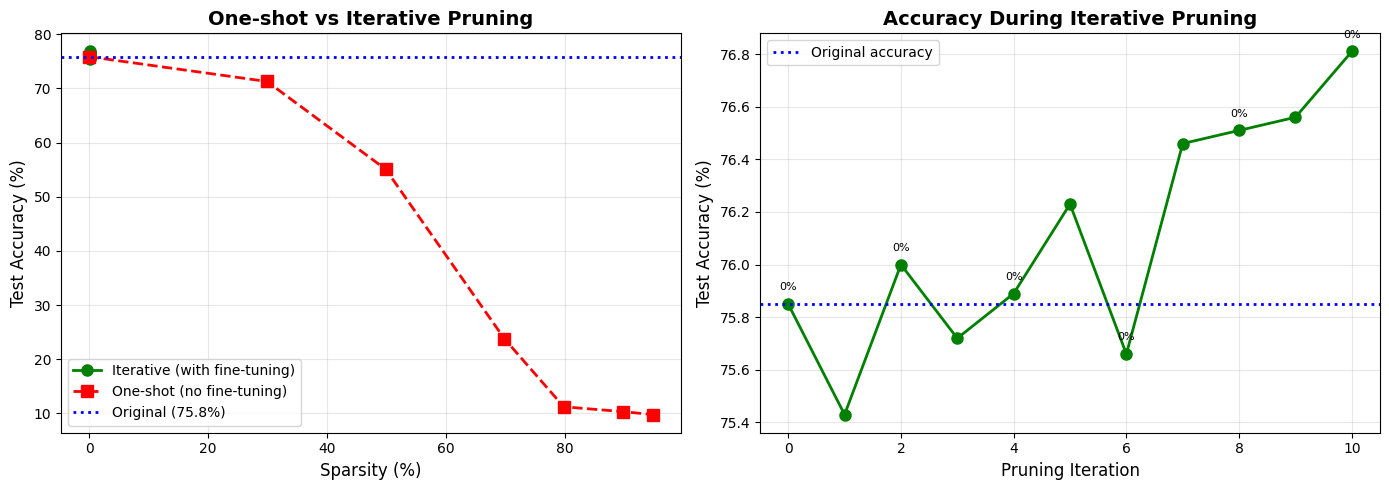


Iterative pruning achieves 0.2% sparsity
with 76.81% accuracy (vs 75.85% original)


In [16]:
# Compare one-shot vs iterative pruning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Iterative pruning trajectory
ax = axes[0]
ax.plot(iter_history['sparsity'], iter_history['accuracy'], 'go-', 
        markersize=8, linewidth=2, label='Iterative (with fine-tuning)')
ax.plot(sparsities, accuracies, 'rs--', 
        markersize=8, linewidth=2, label='One-shot (no fine-tuning)')
ax.axhline(y=best_acc, color='blue', linestyle=':', linewidth=2, label=f'Original ({best_acc:.1f}%)')

ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('One-shot vs Iterative Pruning', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: Accuracy over iterations
ax = axes[1]
ax.plot(iter_history['iteration'], iter_history['accuracy'], 'go-', markersize=8, linewidth=2)
ax.axhline(y=best_acc, color='blue', linestyle=':', linewidth=2, label=f'Original accuracy')

for i, (it, sp, acc) in enumerate(zip(iter_history['iteration'], 
                                       iter_history['sparsity'], 
                                       iter_history['accuracy'])):
    if i % 2 == 0:
        ax.annotate(f'{sp:.0f}%', (it, acc), textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=8)

ax.set_xlabel('Pruning Iteration', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Accuracy During Iterative Pruning', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nIterative pruning achieves {iter_history['sparsity'][-1]:.1f}% sparsity")
print(f"with {iter_history['accuracy'][-1]:.2f}% accuracy (vs {best_acc:.2f}% original)")


## Part 5: PyTorch Pruning Utilities

PyTorch provides built-in pruning utilities in `torch.nn.utils.prune` that handle:

- Creating and managing masks
- Various pruning methods (L1, random, Ln)
- Global vs local pruning
- Making pruning permanent

Let's explore these utilities!


In [17]:
# Create a fresh model for PyTorch pruning demo
model_pytorch = SimpleNet(num_classes=num_classes).to(device)
model_pytorch.load_state_dict(copy.deepcopy(best_model_state))

print("PyTorch Pruning Demo")
print("=" * 60)

# Inspect a layer before pruning
conv1 = model_pytorch.features[0]
print(f"\nBefore pruning:")
print(f"  conv1.weight shape: {conv1.weight.shape}")
print(f"  Parameters: {[name for name, _ in conv1.named_parameters()]}")
print(f"  Buffers: {[name for name, _ in conv1.named_buffers()]}")


PyTorch Pruning Demo

Before pruning:
  conv1.weight shape: torch.Size([32, 3, 3, 3])
  Parameters: ['weight', 'bias']
  Buffers: []


In [18]:
# Apply L1 unstructured pruning to conv1
prune.l1_unstructured(conv1, name='weight', amount=0.3)

print("After pruning (30% L1 unstructured):")
print(f"  Parameters: {[name for name, _ in conv1.named_parameters()]}")
print(f"  Buffers: {[name for name, _ in conv1.named_buffers()]}")

# PyTorch creates:
# - weight_orig: original weights
# - weight_mask: binary mask
# - weight: computed as weight_orig * weight_mask (via forward_pre_hook)

print(f"\n  weight_orig shape: {conv1.weight_orig.shape}")
print(f"  weight_mask shape: {conv1.weight_mask.shape}")
print(f"  Mask sparsity: {(conv1.weight_mask == 0).float().mean() * 100:.1f}%")


After pruning (30% L1 unstructured):
  Parameters: ['bias', 'weight_orig']
  Buffers: ['weight_mask']

  weight_orig shape: torch.Size([32, 3, 3, 3])
  weight_mask shape: torch.Size([32, 3, 3, 3])
  Mask sparsity: 30.0%


In [19]:
# Global pruning across multiple layers
model_global = SimpleNet(num_classes=num_classes).to(device)
model_global.load_state_dict(copy.deepcopy(best_model_state))

# Collect parameters to prune
parameters_to_prune = []
for name, module in model_global.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        parameters_to_prune.append((module, 'weight'))

print(f"Pruning {len(parameters_to_prune)} layers globally")

# Apply global unstructured pruning
prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=0.5,  # 50% globally
)

# Check sparsity per layer
print("\nSparsity per layer after global pruning:")
for name, module in model_global.named_modules():
    if isinstance(module, (nn.Conv2d, nn.Linear)):
        if hasattr(module, 'weight_mask'):
            sparsity = (module.weight_mask == 0).float().mean() * 100
            print(f"  {name}: {sparsity:.1f}%")

# Evaluate
_, acc_global = evaluate(model_global, test_loader, criterion, device)
print(f"\nGlobal pruning (50%): Accuracy = {acc_global:.2f}% (original: {best_acc:.2f}%)")


Pruning 5 layers globally

Sparsity per layer after global pruning:
  features.0: 22.5%
  features.4: 51.2%
  features.8: 52.8%
  classifier.1: 27.8%
  classifier.3: 15.3%

Global pruning (50%): Accuracy = 55.06% (original: 75.85%)


## Summary and Best Practices

### Key Takeaways

1. **Neural networks are highly redundant** - 90%+ weights can often be removed

2. **Unstructured vs Structured Pruning**:
   - Unstructured: Higher compression, needs sparse hardware
   - Structured: Direct speedup, works everywhere

3. **Pruning Criteria**:
   - Magnitude-based is simple and effective
   - Global pruning > layer-wise pruning
   - More sophisticated criteria (gradient, activation) can help

4. **Iterative Pruning** recovers accuracy at high sparsity

5. **Combine with other techniques**: Prune → Quantize → Distill

### Practical Workflow

```
1. Train dense model to convergence
2. Apply global magnitude pruning (start with 50%)
3. Fine-tune for a few epochs
4. Repeat until target sparsity
5. Make pruning permanent
6. (Optional) Apply quantization
```

### Recommended Resources

- [The Lottery Ticket Hypothesis](https://arxiv.org/abs/1803.03635) - Frankle & Carlin (2019)
- [Learning Both Weights and Connections](https://arxiv.org/abs/1506.02626) - Han et al. (2015)
- [PyTorch Pruning Tutorial](https://pytorch.org/tutorials/intermediate/pruning_tutorial.html)
